In [1]:
import pickle
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
from scipy.stats import linregress
from fooof import FOOOF
import sys
import os

sys.path.append(os.path.abspath('..'))
from ERPtools import BANDS, process_band_states

/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_1152/612806800.py:6: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [3]:

with open('/Users/bowmannovey/Desktop/Gangully_Proj/Decay/real_robot_long_data.pkl', 'rb') as f:
    long_data = pickle.load(f)

# Flatten all days into one dict
all_long_combined = {}
for date_folder, sessions in long_data.items():
    for session, files in sessions.items():
        key = f"{date_folder}/{session}"
        all_long_combined[key] = files

print(f"Combined: {len(all_long_combined)} sessions, {sum(len(v) for v in all_long_combined.values())} files")

Combined: 87 sessions, 609 files


In [9]:
target_action = 7
target_7_data = {}

for session_key, files_dict in all_long_combined.items():
    filtered_files = {}
    for f_key, data in files_dict.items():
        if 'TargetID' in data:
            # Check if our target action is present anywhere in the TargetID array for this file
            target_array = np.array(data['TargetID']).flatten()
            if target_action in target_array:
                filtered_files[f_key] = data
                
    # If this session has any files matching target 7, add them to our filtered dictionary
    if filtered_files:
        target_7_data[session_key] = filtered_files

# Print summary of the filtering
print(f"Filtered data to Target {target_action} (Clicking):")
print(f"Original Data: {len(all_long_combined)} sessions, {sum(len(v) for v in all_long_combined.values())} files")
print(f"Filtered Data: {len(target_7_data)} sessions, {sum(len(v) for v in target_7_data.values())} files")

Filtered data to Target 7 (Clicking):
Original Data: 87 sessions, 609 files
Filtered Data: 87 sessions, 87 files


Processing Delta band...
  [Delta] Processing trial 1
  [Delta] Processing trial 2
  [Delta] Processing trial 3
  [Delta] Processing trial 4
  [Delta] Processing trial 5
  [Delta] Processing trial 6
  [Delta] Processing trial 7
  [Delta] Processing trial 8
  [Delta] Processing trial 9
  [Delta] Processing trial 10
  [Delta] Processing trial 11
  [Delta] Processing trial 12
  [Delta] Processing trial 13
  [Delta] Processing trial 14
  [Delta] Processing trial 15
  [Delta] Processing trial 16
  [Delta] Processing trial 17
  [Delta] Processing trial 18
  [Delta] Processing trial 19
  [Delta] Processing trial 20
  [Delta] Processing trial 21
  [Delta] Processing trial 22
  [Delta] Processing trial 23
  [Delta] Processing trial 24
  [Delta] Processing trial 25
  [Delta] Processing trial 26
  [Delta] Processing trial 27
  [Delta] Processing trial 28
  [Delta] Processing trial 29
  [Delta] Processing trial 30
  [Delta] Processing trial 31
  [Delta] Processing trial 32
  [Delta] Processing tri

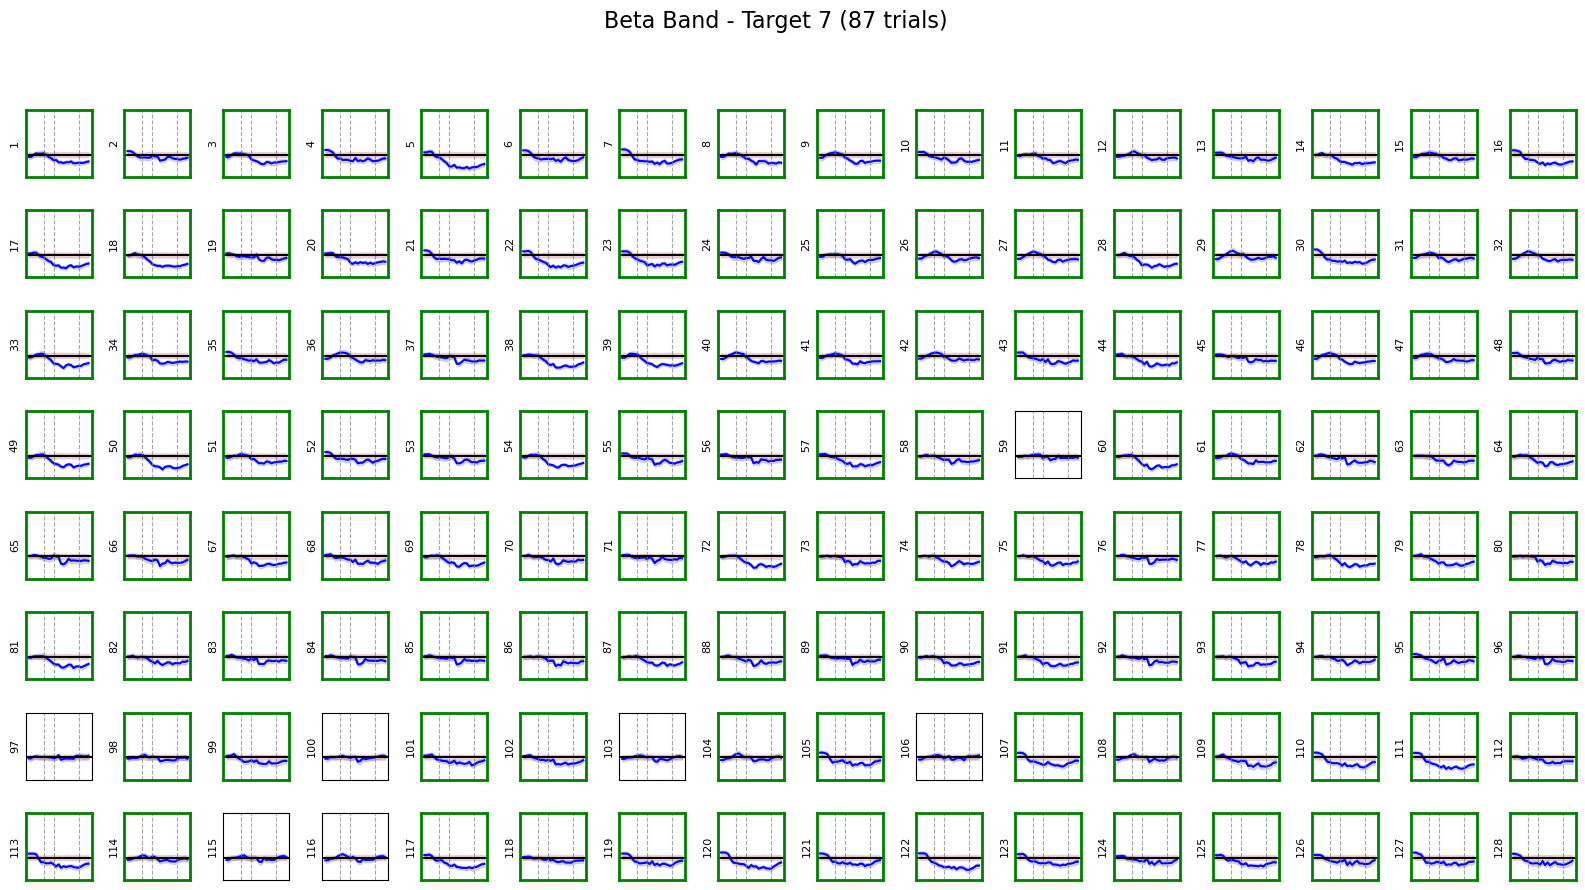

  Target 1: No data. Skipping.
  Target 2: No data. Skipping.
  Target 3: No data. Skipping.
  Target 4: No data. Skipping.
  Target 5: No data. Skipping.
  Target 6: No data. Skipping.
  Target 7: 87 trials, 25 timepoints


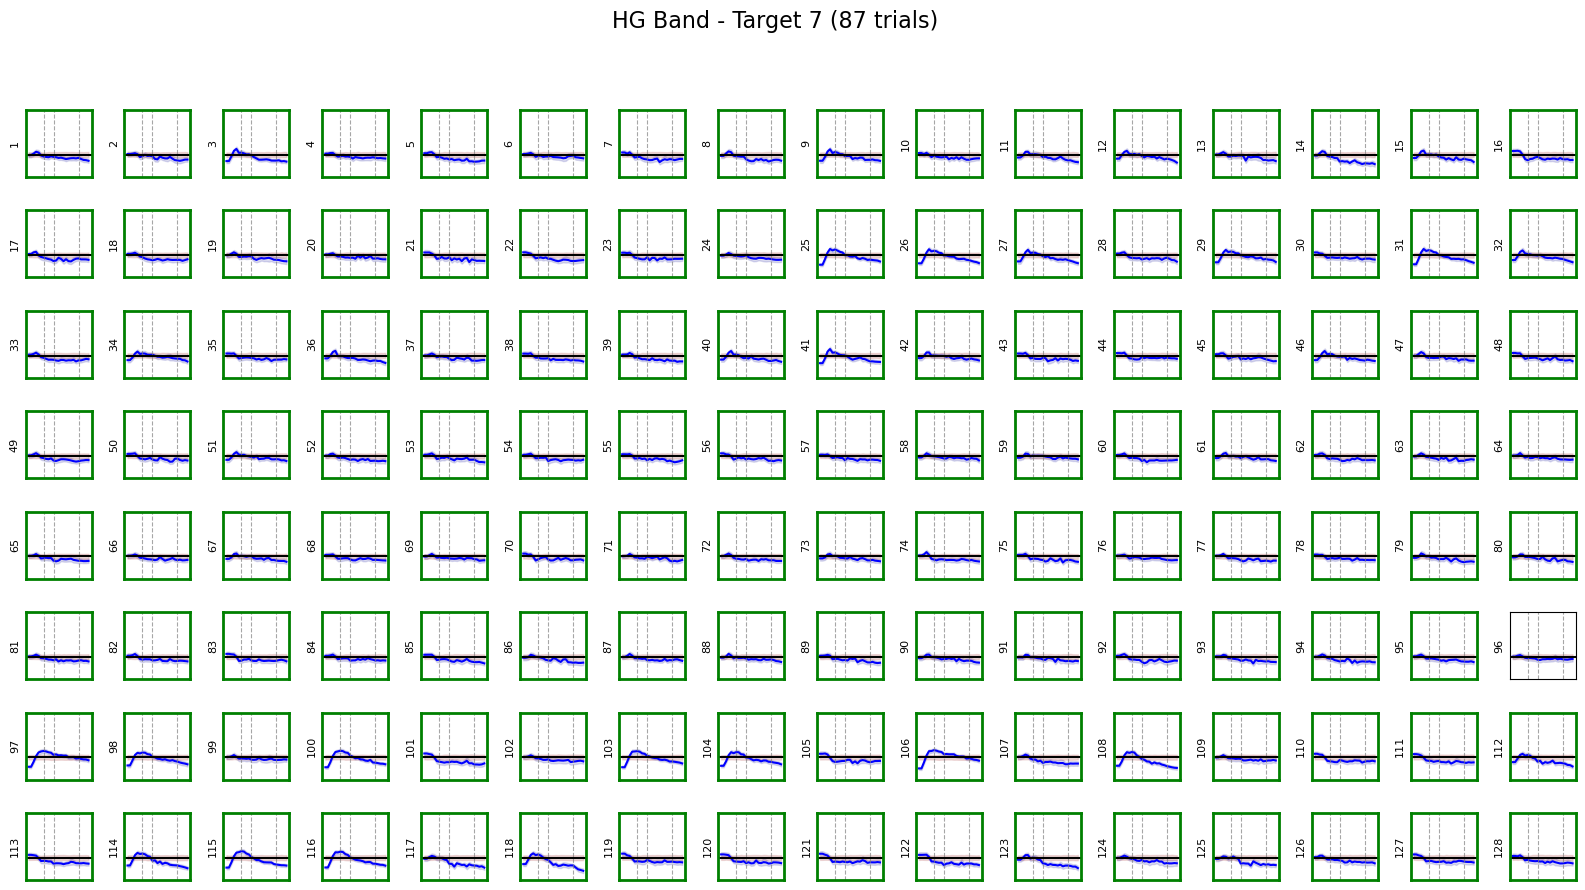

In [11]:
from ERPtools import plot_erps, process_band_states, BANDS

results_long = {}

# Process each band and store the results
for band_name, (start_idx, end_idx) in BANDS.items():
    print(f"Processing {band_name} band...")
    # Pass all_long_combined directly instead of wrapping it in another dict
    D_dict, time_to_target, state_lengths = process_band_states(target_7_data, band_name, start_idx, end_idx)
    results_long[band_name] = {
        'D': D_dict,
        'time_to_target': time_to_target,
        'state_lengths': state_lengths
    }

# The plot_erps function computes the significance (permutation/bootstrap) 
# and plots the ERP data for a given band.
plot_erps(results_long, 'Beta') 
plot_erps(results_long, "HG")# You can change 'Beta' to other bands like 'Delta', 'Theta', etc.

Plotting overlaid Beta and HG for Target 7. Processing significance... (this may take a moment)


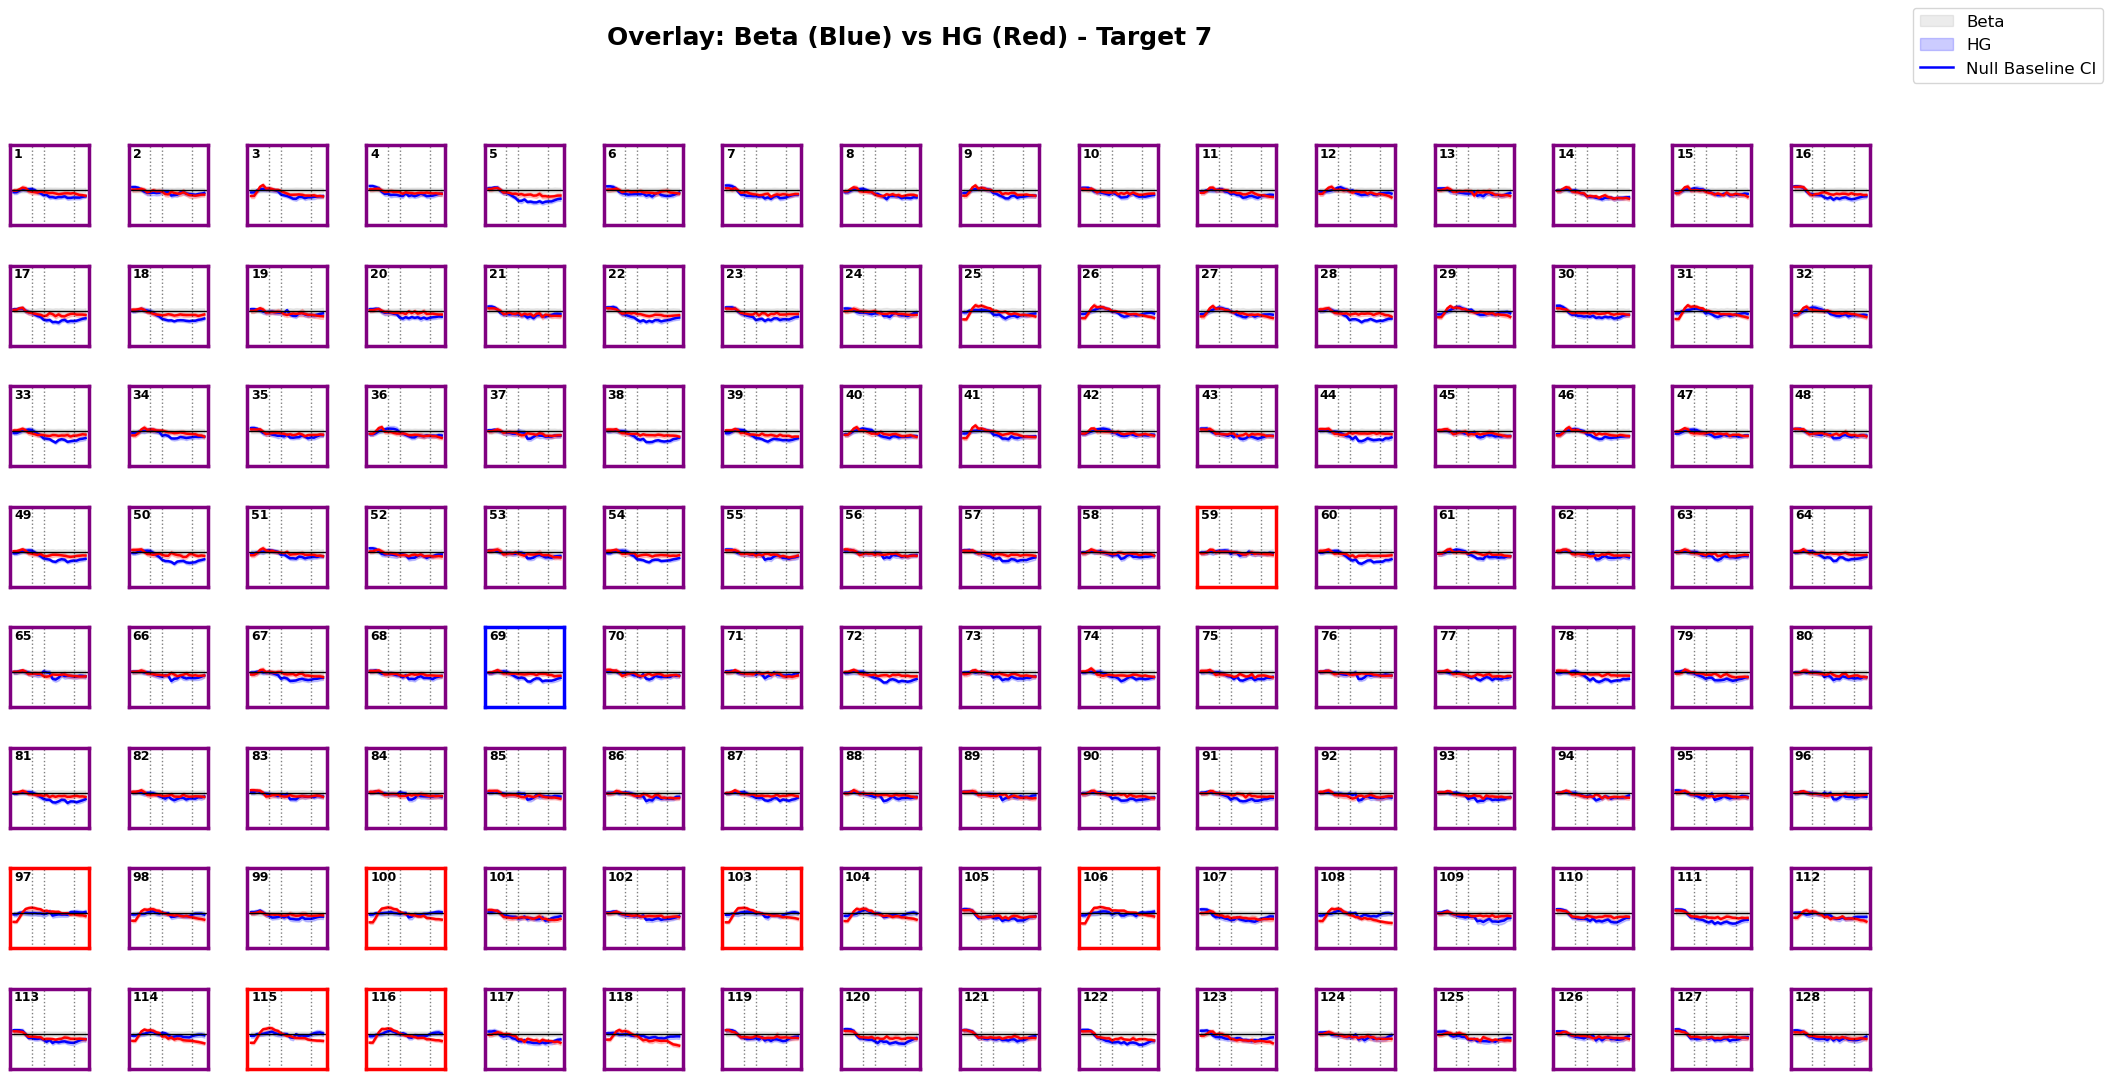

In [12]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

def plot_erps_overlay(results, band1, band2, target_id=7, ch_map=None):
    """
    Plots two different band ERPs overlaid on the same channel grid, 
    with their statistical sampled baselines.
    """
    D1 = results[band1]['D']
    D2 = results[band2]['D']
    
    state_lengths = results[band1].get('state_lengths')
    state_boundaries = []
    if state_lengths:
        cumsum = 0
        for s_len in state_lengths[:-1]:
            cumsum += s_len
            state_boundaries.append(cumsum)

    if ch_map is None:
        ch_map = np.arange(1, 129).reshape(8, 16)

    if D1[target_id].size == 0 or D2[target_id].size == 0:
        print(f"Missing data for target {target_id} in one of the bands.")
        return

    data1 = D1[target_id]
    data2 = D2[target_id]
    num_channels, total_time, _ = data1.shape

    fig = plt.figure(figsize=(24, 12))
    fig.suptitle(f"Overlay: {band1} (Blue) vs {band2} (Red) - Target {target_id}", fontsize=18, fontweight='bold')
    fig.patch.set_facecolor('white')
    gs = GridSpec(8, 16, figure=fig, hspace=0.5, wspace=0.5)
    
    axes = {}
    for row in range(8):
        for col in range(16):
            axes[(row, col)] = fig.add_subplot(gs[row, col])
            
    print(f"Plotting overlaid {band1} and {band2} for Target {target_id}. Processing significance... (this may take a moment)")
            
    # Process each channel
    for ch_idx in range(1, min(num_channels + 1, 129)):
        pos = np.where(ch_map == ch_idx)
        if len(pos[0]) == 0:
            continue
        row, col = pos[0][0], pos[1][0]
        ax = axes[(row, col)]

        def get_plot_data(chdata):
            baseline = chdata[:, :8]
            m_base = np.mean(baseline)
            s_base = np.std(baseline)
            chdata = (chdata - m_base) / (s_base + 1e-10)
            m = np.mean(chdata, axis=0)
            
            # Bootstrap CI (reduced to 250 iterations for faster rendering in overlay)
            mb_samples = []
            for _ in range(250): 
                boot_idx = np.random.choice(chdata.shape[0], chdata.shape[0], replace=True)
                mb_samples.append(np.mean(chdata[boot_idx, :], axis=0))
            mb_samples = np.array(mb_samples)
            ci_low = np.percentile(mb_samples, 2.5, axis=0)
            ci_high = np.percentile(mb_samples, 97.5, axis=0)
            
            # Permutation Null Samples
            null_samples = []
            for _ in range(250):
                tmp = chdata.copy().flatten()
                np.random.shuffle(tmp)
                tmp = tmp.reshape(chdata.shape)
                baseline_null = tmp[:, :8]
                m_null = np.mean(baseline_null)
                s_null = np.std(baseline_null)
                tmp_norm = (tmp - m_null) / (s_null + 1e-10)
                null_samples.append(np.mean(tmp_norm, axis=0))
            null_samples = np.array(null_samples)
            null_low = np.percentile(null_samples, 2.5, axis=0)
            null_high = np.percentile(null_samples, 97.5, axis=0)
            
            # Sig calculation (p >= 0.95 vs null for at least 7 consecutive/total bins)
            pvals = [np.sum(np.abs(m[idx]) >= np.abs(null_samples[:, idx])) / float(null_samples.shape[0]) for idx in range(total_time)]
            is_significant = np.sum(np.array(pvals) >= 0.95) >= 7
            
            return m, ci_low, ci_high, null_low, null_high, is_significant

        # Get stats for both bands
        m1, ci1_l, ci1_h, n1_l, n1_h, sig1 = get_plot_data(data1[ch_idx - 1, :, :].T)
        m2, ci2_l, ci2_h, n2_l, n2_h, sig2 = get_plot_data(data2[ch_idx - 1, :, :].T)
        
        tt = np.arange(total_time)
        
        # Plot Statistical Null Baseline Area (combining min/max to show general baseline envelope for both)
        ax.fill_between(tt, np.minimum(n1_l, n2_l), np.maximum(n1_h, n2_h), color='gray', alpha=0.15)
        
        # Plot Band 1 (Beta -> Blue)
        ax.fill_between(tt, ci1_l, ci1_h, color='blue', alpha=0.2)
        ax.plot(tt, m1, color='blue', linewidth=1.8, label=band1)
        
        # Plot Band 2 (HG -> Red)
        ax.fill_between(tt, ci2_l, ci2_h, color='red', alpha=0.2)
        ax.plot(tt, m2, color='red', linewidth=1.8, label=band2)

        for boundary in state_boundaries:
            ax.axvline(x=boundary, color='k', linestyle=':', linewidth=1.0, alpha=0.5)

        ax.text(0.05, 0.85, str(ch_idx), transform=ax.transAxes, fontsize=9, fontweight='bold')
        ax.set_ylim([-3.5, 4.5])
        ax.axhline(0, color='k', linewidth=1.0)
        ax.set_xticks([])
        ax.set_yticks([])

        # Mark significant border: Purple (Both), Blue (Band 1 only), Red (Band 2 only)
        border_color = None
        if sig1 and sig2:
            border_color = 'purple'
        elif sig1:
            border_color = 'blue'
        elif sig2:
            border_color = 'red'
            
        if border_color:
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(2.5)

    # Adding a custom legend to the last unused axis or top right of the figure
    fig.legend([band1, band2, 'Null Baseline CI'], loc='upper right', fontsize=12)

    plt.show()

# Run the overlay plot matching Target 7
plot_erps_overlay(results_long, 'Beta', 'HG', target_id=7)

Processing significance for Target 7, Channel 69...


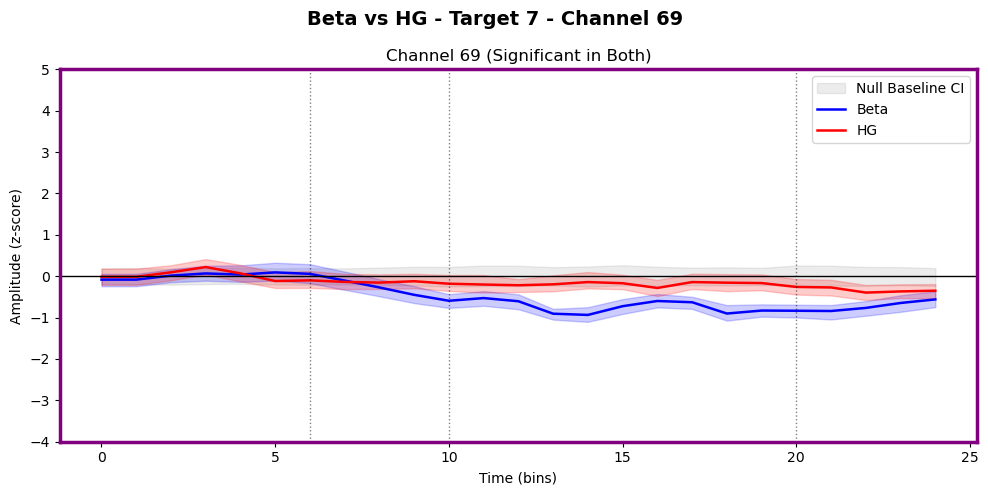

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_single_channel_overlay(results, band1, band2, ch_idx, target_id=7):
    """
    Plots two different band ERPs overlaid for a single, specific channel, 
    with their statistical sampled baselines.
    """
    D1 = results[band1]['D']
    D2 = results[band2]['D']
    
    state_lengths = results[band1].get('state_lengths')
    state_boundaries = []
    if state_lengths:
        cumsum = 0
        for s_len in state_lengths[:-1]:
            cumsum += s_len
            state_boundaries.append(cumsum)

    if D1[target_id].size == 0 or D2[target_id].size == 0:
        print(f"Missing data for target {target_id} in one of the bands.")
        return

    data1 = D1[target_id]
    data2 = D2[target_id]
    num_channels, total_time, _ = data1.shape

    if ch_idx > num_channels or ch_idx < 1:
        print(f"Channel {ch_idx} is out of range.")
        return

    print(f"Processing significance for Target {target_id}, Channel {ch_idx}...")
    
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle(f"{band1} vs {band2} - Target {target_id} - Channel {ch_idx}", fontsize=14, fontweight='bold')
    fig.patch.set_facecolor('white')

    def get_plot_data(chdata):
        baseline = chdata[:, :8]
        m_base = np.mean(baseline)
        s_base = np.std(baseline)
        chdata = (chdata - m_base) / (s_base + 1e-10)
        m = np.mean(chdata, axis=0)
        
        # Bootstrap CI (250 iterations)
        mb_samples = []
        for _ in range(250): 
            boot_idx = np.random.choice(chdata.shape[0], chdata.shape[0], replace=True)
            mb_samples.append(np.mean(chdata[boot_idx, :], axis=0))
        mb_samples = np.array(mb_samples)
        ci_low = np.percentile(mb_samples, 2.5, axis=0)
        ci_high = np.percentile(mb_samples, 97.5, axis=0)
        
        # Permutation Null Samples
        null_samples = []
        for _ in range(250):
            tmp = chdata.copy().flatten()
            np.random.shuffle(tmp)
            tmp = tmp.reshape(chdata.shape)
            baseline_null = tmp[:, :8]
            m_null = np.mean(baseline_null)
            s_null = np.std(baseline_null)
            tmp_norm = (tmp - m_null) / (s_null + 1e-10)
            null_samples.append(np.mean(tmp_norm, axis=0))
        null_samples = np.array(null_samples)
        null_low = np.percentile(null_samples, 2.5, axis=0)
        null_high = np.percentile(null_samples, 97.5, axis=0)
        
        # Sig calculation
        pvals = [np.sum(np.abs(m[idx]) >= np.abs(null_samples[:, idx])) / float(null_samples.shape[0]) for idx in range(total_time)]
        is_significant = np.sum(np.array(pvals) >= 0.95) >= 7
        
        return m, ci_low, ci_high, null_low, null_high, is_significant

    # Get stats for both bands
    m1, ci1_l, ci1_h, n1_l, n1_h, sig1 = get_plot_data(data1[ch_idx - 1, :, :].T)
    m2, ci2_l, ci2_h, n2_l, n2_h, sig2 = get_plot_data(data2[ch_idx - 1, :, :].T)
    
    tt = np.arange(total_time)
    
    # Plot Statistical Null Baseline Area
    ax.fill_between(tt, np.minimum(n1_l, n2_l), np.maximum(n1_h, n2_h), color='gray', alpha=0.15, label='Null Baseline CI')
    
    # Plot Band 1 (Beta -> Blue)
    ax.fill_between(tt, ci1_l, ci1_h, color='blue', alpha=0.2)
    ax.plot(tt, m1, color='blue', linewidth=1.8, label=band1)
    
    # Plot Band 2 (HG -> Red)
    ax.fill_between(tt, ci2_l, ci2_h, color='red', alpha=0.2)
    ax.plot(tt, m2, color='red', linewidth=1.8, label=band2)

    for boundary in state_boundaries:
        ax.axvline(x=boundary, color='k', linestyle=':', linewidth=1.0, alpha=0.5)

    ax.set_ylim([-4, 5])
    ax.set_ylabel('Amplitude (z-score)')
    ax.set_xlabel('Time (bins)')
    ax.axhline(0, color='k', linewidth=1.0)
    
    # Define significant border colors
    border_color = None
    if sig1 and sig2:
        border_color = 'purple'
        title_suffix = " (Significant in Both)"
    elif sig1:
        border_color = 'blue'
        title_suffix = f" (Significant in {band1})"
    elif sig2:
        border_color = 'red'
        title_suffix = f" (Significant in {band2})"
    else:
        title_suffix = " (Not Significant)"
        
    ax.set_title(f"Channel {ch_idx}{title_suffix}")

    if border_color:
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(2.5)

    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Example: Plot an individual channel (e.g. channel number 80)
plot_single_channel_overlay(results_long, 'Beta', 'HG', ch_idx=69, target_id=7)

# To plot multiple individual channels at once, you could loop through them like this:
# for ch in [15, 30, 80]:
#     plot_single_channel_overlay(results_long, 'Beta', 'HG', ch_idx=ch, target_id=7)

In [16]:
import numpy as np
import pandas as pd

def generate_stats_report(results, band1, band2, target_id=7):
    """
    Generates a statistical summary report of responsive channels 
    based on the permutation tests.
    """
    D1 = results[band1]['D']
    D2 = results[band2]['D']
    
    if D1[target_id].size == 0 or D2[target_id].size == 0:
        print(f"Missing data for target {target_id}")
        return

    data1 = D1[target_id]
    data2 = D2[target_id]
    num_channels, total_time, _ = data1.shape

    sig_band1_only = []
    sig_band2_only = []
    sig_both = []
    
    stats_data = []

    print(f"Calculating statistics for Target {target_id}...")
    
    for ch_idx in range(1, min(num_channels + 1, 129)):
        def get_channel_stats(chdata):
            baseline = chdata[:, :8]
            m_base = np.mean(baseline)
            s_base = np.std(baseline)
            chdata = (chdata - m_base) / (s_base + 1e-10)
            m = np.mean(chdata, axis=0)
            
            # Permutation Null Samples
            null_samples = []
            for _ in range(100): # Fast approximation for report
                tmp = chdata.copy().flatten()
                np.random.shuffle(tmp)
                tmp = tmp.reshape(chdata.shape)
                baseline_null = tmp[:, :8]
                m_null = np.mean(baseline_null)
                s_null = np.std(baseline_null)
                tmp_norm = (tmp - m_null) / (s_null + 1e-10)
                null_samples.append(np.mean(tmp_norm, axis=0))
            null_samples = np.array(null_samples)
            
            pvals = [np.sum(np.abs(m[idx]) >= np.abs(null_samples[:, idx])) / float(null_samples.shape[0]) for idx in range(total_time)]
            sig_bins = np.sum(np.array(pvals) >= 0.95)
            is_significant = sig_bins >= 7
            
            peak_z = np.max(np.abs(m))
            return is_significant, peak_z

        sig1, peak1 = get_channel_stats(data1[ch_idx - 1, :, :].T)
        sig2, peak2 = get_channel_stats(data2[ch_idx - 1, :, :].T)
        
        if sig1 or sig2:
            stats_data.append({
                'Channel': ch_idx,
                f'{band1} Significant': sig1,
                f'{band2} Significant': sig2,
                f'{band1} Peak z-score': round(peak1, 2),
                f'{band2} Peak z-score': round(peak2, 2)
            })
            
        if sig1 and sig2:
            sig_both.append(ch_idx)
        elif sig1:
            sig_band1_only.append(ch_idx)
        elif sig2:
            sig_band2_only.append(ch_idx)

    # Print summary
    print("=" * 50)
    print(f"STATISTICAL SUMMARY: TARGET {target_id} (Clicking)")
    print("=" * 50)
    print(f"Total responsive channels: {len(sig_both) + len(sig_band1_only) + len(sig_band2_only)} / {num_channels}")
    print(f"- Significant in BOTH {band1} & {band2}: {len(sig_both)} channels")
    print(f"  {sig_both}\n")
    print(f"- Significant in {band1} ONLY: {len(sig_band1_only)} channels")
    print(f"  {sig_band1_only}\n")
    print(f"- Significant in {band2} ONLY: {len(sig_band2_only)} channels")
    print(f"  {sig_band2_only}\n")
    
    # Return as DataFrame for easy viewing
    df = pd.DataFrame(stats_data)
    if not df.empty:
        df = df.sort_values(by=[f'{band2} Significant', f'{band1} Significant'], ascending=False).reset_index(drop=True)
    return df

# Generate and display the stats report
stats_df = generate_stats_report(results_long, 'Beta', 'HG', target_id=7)
stats_df.head(20) # Display top 20 significant channels

Calculating statistics for Target 7...
STATISTICAL SUMMARY: TARGET 7 (Clicking)
Total responsive channels: 128 / 128
- Significant in BOTH Beta & HG: 121 channels
  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 98, 99, 101, 102, 104, 105, 107, 108, 109, 110, 111, 112, 113, 114, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128]

- Significant in Beta ONLY: 0 channels
  []

- Significant in HG ONLY: 7 channels
  [59, 97, 100, 103, 106, 115, 116]



,Channel,Beta Significant,HG Significant,Beta Peak z-score,HG Peak z-score
0,1,True,True,0.77,0.55
1,2,True,True,0.54,0.55
2,3,True,True,0.86,0.62
3,4,True,True,0.61,0.35
4,5,True,True,1.26,0.64
5,6,True,True,0.63,0.33
6,7,True,True,0.86,0.67
7,8,True,True,0.90,0.62
8,9,True,True,0.82,0.56
9,10,True,True,0.73,0.46
